### Introduction

This notebook assesses the quality of the smartwatch sensor recordings contained in the movement dataset of the Parkinson's Disease Smartwatch (PADS) database. The analysis focuses on the accelerometer and gyroscope signals collected during neurological assessment tasks to verify that the recordings are complete, valid, and suitable for feature extraction and machine learning.

Dataset located in: "data/raw/movement"

This directory contains two types of files:

##### a. Observation JSON files
These files store metadata describing each participant's neurological assessment sessions, including:

- Participant identifier
- Assessment task name
- Sampling rate
- Number of recorded samples
- Sensor channels
- Device location (LeftWrist or RightWrist)
- Reference to the corresponding time-series file

##### b. Time-series files (timeseries/*.txt)
These files contain the raw smartwatch measurements recorded during each neurological assessment task. Each file includes the following channels:

- Time
- Accelerometer_X
- Accelerometer_Y
- Accelerometer_Z
- Gyroscope_X
- Gyroscope_Y
- Gyroscope_Z

These raw signals constitute the primary data source for the signal quality assessment performed

#### Objetive

- Process and review accelerometer and gyroscope time-series data from all participants.
- Evaluate the completeness and availability of sensor channels across participants and assessment conditions.
- Identify and characterize signal quality issues, noisy, incomplete, or invalid sensor recordings.
- Perform exploratory visualization of representative accelerometer and gyroscope signals.
- Develop a Signal Quality Report summarizing 
- Establish signal-quality assessment rules based on exploratory analysis results.

#### 1. Loaing Raw Signal Data

In [4]:
# Impor libraries
from pathlib import Path
import json
import pandas as pd

# Define paths
movement_path = Path("../data/raw/movement")

print(f"Movement directory: {movement_path.resolve()}")
print(f"Directory exists: {movement_path.exists()}")

# Read all JSON files
json_files = sorted(movement_path.glob("*.json"))

print(f"Number of files: {len(json_files)}")

Movement directory: C:\Users\Main\Documents\GitHub\AI-Assisted-Screening-of-Parkinson-s-Disease\data\raw\movement
Directory exists: True
Number of files: 469


In [7]:
# Load the files
sensor_data = []

for file in json_files:
    with open(file, "r") as f:
        sensor_data.append(json.load(f))

print(f"Loaded {len(sensor_data)} recordings.")

# Verify that they were loaded correctly
print(sensor_data[0].keys())

Loaded 469 recordings.
dict_keys(['resource_type', 'subject_id', 'study_id', 'device_id', 'id', 'endianness', 'sampling_rate', 'data_type', 'bits', 'session'])


#### 2. Inspecting the Dataset Structure
Verify the completeness of sensor channels for each participant and assessment task.

In [139]:
from pprint import pprint

In [140]:
# Verify the completeness of sensor channels
required_channels = {
    "Time",
    "Accelerometer_X",
    "Accelerometer_Y",
    "Accelerometer_Z",
    "Gyroscope_X",
    "Gyroscope_Y",
    "Gyroscope_Z"
}

In [141]:
completeness = []

for observation in sensor_data:

    subject = observation["subject_id"]

    for session in observation["session"]:

        task = session["record_name"]

        for record in session["records"]:

            location = record["device_location"]

            channels = set(record["channels"])

            missing = required_channels - channels

            completeness.append({
                "Subject": subject,
                "Task": task,
                "Location": location,
                "Complete": len(missing) == 0,
                "Missing Channels": ", ".join(sorted(missing)) if missing else "None"
            })

completeness_df = pd.DataFrame(completeness)

completeness_df.head()

,Subject,Task,Location,Complete,Missing Channels
0,001,Relaxed,LeftWrist,True,None
1,001,Relaxed,RightWrist,True,None
2,001,RelaxedTask,LeftWrist,True,None
3,001,RelaxedTask,RightWrist,True,None
4,001,StretchHold,LeftWrist,True,None


#### 3. Detect constant, noisy, incomplete, or invalid signals

Evaluate the quality of every accelerometer and gyroscope recording by checking signal completeness, missing values, constant channels and invalid values

#### 3.1 Load and Inspect a Sample Signal

In [ ]:
# Define the folder where the time series (.txt) are located.
timeseries_path = Path("../data/raw/movement/timeseries")

print(timeseries_path.exists())

True


In [61]:
# sensor_data[0] correspont to observation_001.json
# Store all txt files from observation_001
observation_files = []

for session in sensor_data[0]["session"]:
    for record in session["records"]:
        observation_files.append(record["file_name"])

print("Number of files:", len(observation_files))
observation_files

Number of files: 22


['timeseries/001_Relaxed_LeftWrist.txt',
 'timeseries/001_Relaxed_RightWrist.txt',
 'timeseries/001_RelaxedTask_LeftWrist.txt',
 'timeseries/001_RelaxedTask_RightWrist.txt',
 'timeseries/001_StretchHold_LeftWrist.txt',
 'timeseries/001_StretchHold_RightWrist.txt',
 'timeseries/001_LiftHold_LeftWrist.txt',
 'timeseries/001_LiftHold_RightWrist.txt',
 'timeseries/001_HoldWeight_LeftWrist.txt',
 'timeseries/001_HoldWeight_RightWrist.txt',
 'timeseries/001_PointFinger_LeftWrist.txt',
 'timeseries/001_PointFinger_RightWrist.txt',
 'timeseries/001_DrinkGlas_LeftWrist.txt',
 'timeseries/001_DrinkGlas_RightWrist.txt',
 'timeseries/001_CrossArms_LeftWrist.txt',
 'timeseries/001_CrossArms_RightWrist.txt',
 'timeseries/001_TouchIndex_LeftWrist.txt',
 'timeseries/001_TouchIndex_RightWrist.txt',
 'timeseries/001_TouchNose_LeftWrist.txt',
 'timeseries/001_TouchNose_RightWrist.txt',
 'timeseries/001_Entrainment_LeftWrist.txt',
 'timeseries/001_Entrainment_RightWrist.txt']

In [109]:
# Open the file and confirm that the data is loaded.
first_file = sensor_data[0]["session"][0]["records"][0]["file_name"]

record_sample = sensor_data[0]["session"][0]["records"][0]

columns = record_sample["channels"]

signal = pd.read_csv(
    timeseries_path / Path(record_sample["file_name"]).name,
    header=None,
    names=columns
)

print(first_file)
signal

timeseries/001_Relaxed_LeftWrist.txt


,Time,Accelerometer_X,Accelerometer_Y,Accelerometer_Z,Gyroscope_X,Gyroscope_Y,Gyroscope_Z
0,0.000000,-0.003958,0.002360,1.746120e-03,-0.015492,0.005616,0.001034
1,0.009903,-0.004005,0.002259,8.355394e-04,-0.012276,0.005605,-0.003218
2,0.019901,0.000833,0.002225,9.437218e-04,-0.009051,0.002432,-0.002137
3,0.029907,-0.000191,0.004109,4.783000e-07,-0.008911,0.002154,-0.000931
4,0.039984,0.001769,0.004064,-1.902400e-03,-0.007830,0.000034,0.000145
...,...,...,...,...,...,...,...
2043,20.419054,-0.003376,0.002929,-2.616500e-05,-0.006734,-0.004036,0.008691
2044,20.429129,-0.005291,0.003816,-3.331750e-05,0.000699,0.001352,0.007590
2045,20.439043,-0.006250,0.003776,-4.958960e-05,0.004943,0.004591,0.007566
2046,20.449083,-0.004288,0.001850,-9.968267e-04,0.008140,0.005674,0.006495


#### 3.2 Perform Signal Quality Assessment for All Recordings

In [110]:
# After confirming that a sample signal can be loaded correctly,
# evaluate the quality of all recordings in the dataset.

# List where we will save the results
quality_results = []

import numpy as np

for observation in sensor_data:

    subject = observation["subject_id"]

    for session in observation["session"]:

        task = session["record_name"]
        expected_rows = session["rows"]

        for record in session["records"]:

            location = record["device_location"]

            columns = record["channels"]

            signal = pd.read_csv(
                timeseries_path / Path(record["file_name"]).name,
                header=None,
                names=columns
            )

            actual_rows = len(signal)

            missing_values = signal.isna().sum().sum()

            constant_channels = signal.columns[signal.std() == 0].tolist()

            invalid_values = np.isinf(signal.values).sum()

            if actual_rows != expected_rows:
                quality = "Incomplete"

            elif missing_values > 0:
                quality = "Missing Values"

            elif invalid_values > 0:
                quality = "Invalid"

            elif len(constant_channels) > 0:
                quality = "Constant"

            else:
                quality = "Valid"

            quality_results.append({

                "Subject": subject,
                "Task": task,
                "Location": location,
                "File": Path(record["file_name"]).name,


                "Expected Rows": expected_rows,
                "Actual Rows": actual_rows,

                "Missing Values": missing_values,
                "Constant Channels": ", ".join(constant_channels) if constant_channels else "None",
                "Invalid Values": invalid_values,

                "Quality": quality

            })

In [111]:
quality_report = pd.DataFrame(quality_results)

print("===== Signal Quality Assessment Summary =====\n")

# Check signal length
if (quality_report["Expected Rows"] == quality_report["Actual Rows"]).all():
    print("All recordings have the expected number of rows.")
else:
    print("Some recordings have an unexpected number of rows.")

# Check missing values
if (quality_report["Missing Values"] == 0).all():
    print("No missing values were found.")
else:
    print("Missing values were detected.")

# Check constant channels
if (quality_report["Constant Channels"] == "None").all():
    print("No constant channels were detected.")
else:
    print("Constant channels were detected.")

# Check invalid values
if (quality_report["Invalid Values"] == 0).all():
    print("No invalid values were found.")
else:
    print("Invalid values were detected.")

# Overall quality
if (quality_report["Quality"] == "Valid").all():
    print("All recordings passed the signal quality assessment.")
else:
    print("Some recordings require inspection.")

quality_report.head()

===== Signal Quality Assessment Summary =====

All recordings have the expected number of rows.
No missing values were found.
No constant channels were detected.
No invalid values were found.
All recordings passed the signal quality assessment.


,Subject,Task,Location,File,Expected Rows,Actual Rows,Missing Values,Constant Channels,Invalid Values,Quality
0,001,Relaxed,LeftWrist,001_Relaxed_LeftWrist.txt,2048,2048,0,None,0,Valid
1,001,Relaxed,RightWrist,001_Relaxed_RightWrist.txt,2048,2048,0,None,0,Valid
2,001,RelaxedTask,LeftWrist,001_RelaxedTask_LeftWrist.txt,2048,2048,0,None,0,Valid
3,001,RelaxedTask,RightWrist,001_RelaxedTask_RightWrist.txt,2048,2048,0,None,0,Valid
4,001,StretchHold,LeftWrist,001_StretchHold_LeftWrist.txt,1024,1024,0,None,0,Valid


Interpretation:

The results indicate that the evaluated recordings meet the expected signal quality requirements. For each participant, assessment task, and device location, the number of recorded samples matches the expected number of rows, confirming that no incomplete signals were detected. 
Additionally, no missing values, constant channels, or invalid values were found in any of the evaluated recordings. Therefore, all analyzed signals were classified as Valid, indicating that the dataset is suitable for subsequent signal processing and analysis.

#### 4. Visualize of Accelerometer and Gyroscope Signals

#### 4.1 Accelerometer signals (right and left)

Subject: 001
Task: Relaxed
Location: LeftWrist
File: 001_Relaxed_LeftWrist.txt


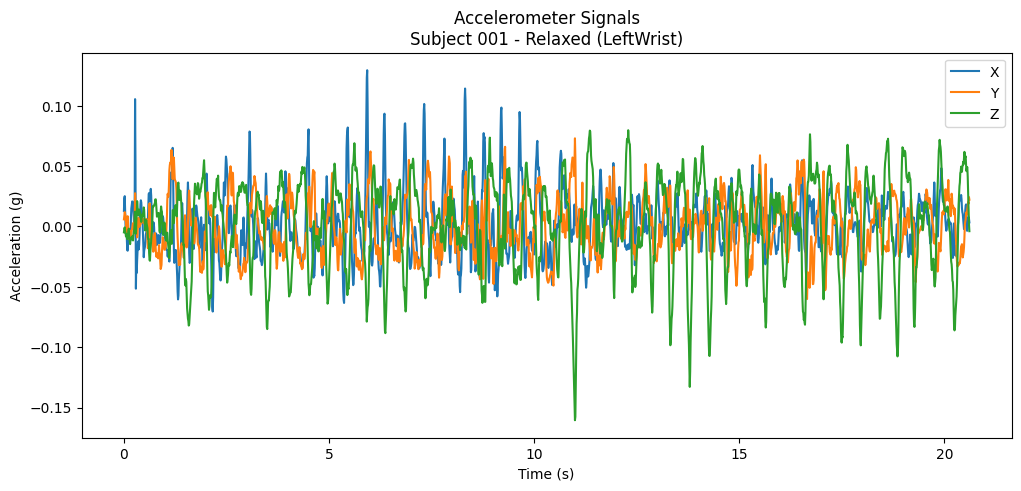

In [134]:
import matplotlib.pyplot as plt

# Select a sample recording (Left) for inspection
observation = sensor_data[0]          # observation_001.json
subject = observation["subject_id"]   # Patient ID

session = observation["session"][0]   # [0] First assessment task
task = session["record_name"]

record_selection_0 = session["records"][0]        # First recording (Left (0) or Right (1) wrist)
location_0 = record_selection_0["device_location"]


# Display information about the selected recording
print(f"Subject: {subject}")
print(f"Task: {task}")
print(f"Location: {location_0}")
print(f"File: {Path(record_selection_0['file_name']).name}")

plt.figure(figsize=(12,5))

plt.plot(signal["Time"], signal["Accelerometer_X"], label="X")
plt.plot(signal["Time"], signal["Accelerometer_Y"], label="Y")
plt.plot(signal["Time"], signal["Accelerometer_Z"], label="Z")

plt.title(
    f"Accelerometer Signals\nSubject {subject} - {task} ({location_0})"
)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.legend()

plt.show()

Subject: 001
Task: Relaxed
Location: RightWrist
File: 001_Relaxed_RightWrist.txt


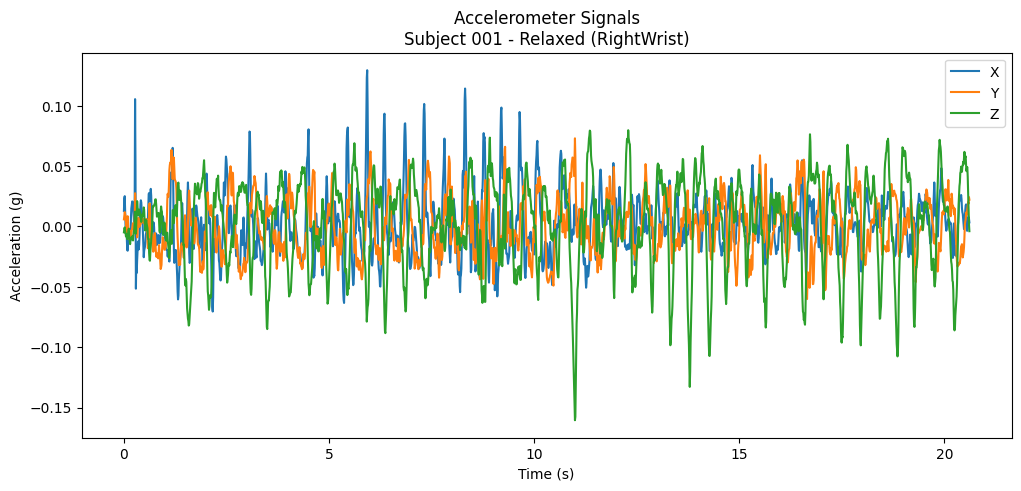

In [135]:
# Select a sample recording (right) for inspection
observation = sensor_data[0]          # observation_001.json
subject = observation["subject_id"]   # Patient ID

session = observation["session"][0]   # [0] First assessment task
task = session["record_name"]

record_selection_1 = session["records"][1]        # First recording (Left (0) or Right (1) wrist)
location_1 = record_selection_1["device_location"]


# Display information about the selected recording
print(f"Subject: {subject}")
print(f"Task: {task}")
print(f"Location: {location_1}")
print(f"File: {Path(record_selection_1['file_name']).name}")

plt.figure(figsize=(12,5))

plt.plot(signal["Time"], signal["Accelerometer_X"], label="X")
plt.plot(signal["Time"], signal["Accelerometer_Y"], label="Y")
plt.plot(signal["Time"], signal["Accelerometer_Z"], label="Z")

plt.title(
    f"Accelerometer Signals\nSubject {subject} - {task} ({location_1})"
)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.legend()

plt.show()



#### 4.2 Gyroscope signal

Subject: 001
Task: Relaxed
Location: RightWrist
File: 001_Relaxed_RightWrist.txt


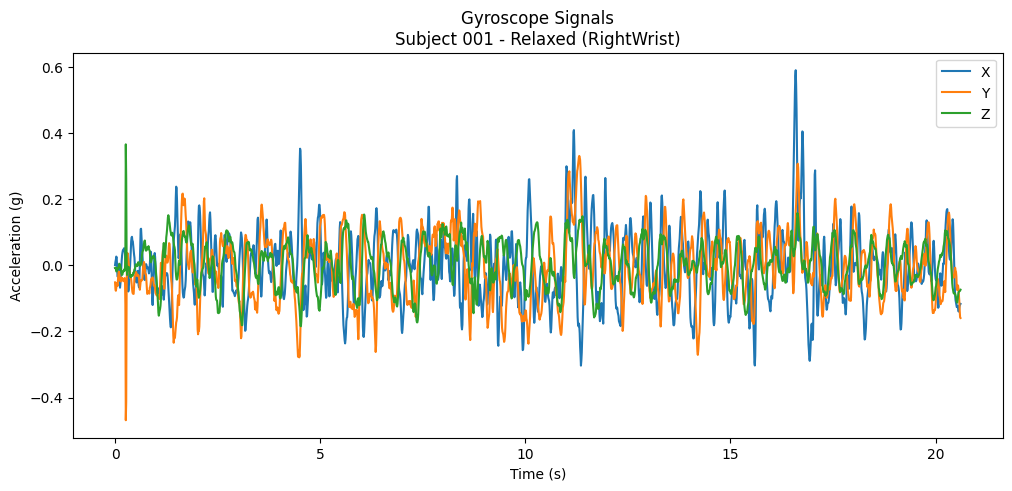

In [137]:
# Display information about the selected recording
print(f"Subject: {subject}")
print(f"Task: {task}")
print(f"Location: {location_1}")                             # Change 0 to left and 1 to right
print(f"File: {Path(record_selection_1['file_name']).name}") # Change 0 to left and 1 to right
plt.figure(figsize=(12,5))

plt.plot(signal["Time"], signal["Gyroscope_X"], label="X")
plt.plot(signal["Time"], signal["Gyroscope_Y"], label="Y")
plt.plot(signal["Time"], signal["Gyroscope_Z"], label="Z")

plt.title(
    f"Gyroscope Signals\nSubject {subject} - {task} ({location_1})" # Change 0 to left and 1 to right
)

plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")
plt.legend()

plt.show()